# Hyperspy experiments

This is a throwaway notebook just for experimenting. **DO NOT** assume anything in here is correct,
makes sense, or for that matter safe to be in the same room with.

In [1]:
#import the modules we'll be using later.

import os, re, json, hashlib
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
import h5py   # Used for HDF5, if we decide to actually use that.
from scipy import ndimage
from scipy.signal import fftconvolve

import hyperspy.api as hs



# First, the simplest use of HyperSpy just to get the blood flowing and limbs limbered up.

In [ ]:
# straight out of the hyperspy example directory. Possibly with some changes. Likely.

import numpy as np
import hyperspy.api as hs

# Create an image stack with random data
im = hs.signals.Signal2D(np.random.random((16, 32, 32)))

# Define the axis properties
im.axes_manager.signal_axes[0].name = 'X'
im.axes_manager.signal_axes[0].units = 'nm'
im.axes_manager.signal_axes[0].scale = 0.1
im.axes_manager.signal_axes[0].offset = 0

im.axes_manager.signal_axes[1].name = 'Y'
im.axes_manager.signal_axes[1].units = 'nm'
im.axes_manager.signal_axes[1].scale = 0.1
im.axes_manager.signal_axes[1].offset = 0

im.axes_manager.navigation_axes[0].name = 'time'
im.axes_manager.navigation_axes[0].units = 'fs'
im.axes_manager.navigation_axes[0].scale = 0.3
im.axes_manager.navigation_axes[0].offset = 100

# Give a title
im.metadata.General.title = 'Random image stack'
# Plot it
im.plot()


## Now let's define some of the convenience functions we were using in the ChatGPT-generated examples.

In [2]:
#straight outta Codex...

#
# === Module 0.1 utilities ===



HAS_TIFFFILE = True
HAS_H5PY = True
HAS_SCIPY = True


def read_tiff(path):
    if HAS_TIFFFILE:
        arr = tiff.imread(path)
        return arr
    import matplotlib.image as mpimg
    arr = mpimg.imread(path)
    if arr.ndim == 3:
        arr = arr.mean(axis=2)
    return arr.astype(float)

def save_jpeg_thumbnail(img2d, out_path, p_low=1, p_high=99, max_size=512):
    img = img2d.astype(float)
    lo, hi = np.percentile(img, [p_low, p_high])
    img = np.clip((img - lo) / (hi - lo + 1e-12), 0, 1)
    H, W = img.shape
    scale = max(H, W) / max_size
    if scale > 1:
        step = int(np.ceil(scale))
        img = img[::step, ::step]
    plt.imsave(out_path, img, cmap=None)

def image_stats(img2d):
    img = img2d.astype(float)
    return {
        "shape": list(img.shape),
        "dtype": str(img2d.dtype),
        "min": float(np.min(img)),
        "max": float(np.max(img)),
        "mean": float(np.mean(img)),
        "std": float(np.std(img)),
        "p1": float(np.percentile(img, 1)),
        "p50": float(np.percentile(img, 50)),
        "p99": float(np.percentile(img, 99))
    }

def sha256_file(path, chunk_size=1024*1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

def safe_mkdir(p):
    Path(p).mkdir(parents=True, exist_ok=True)

# Go on and turn off traitsui gui on the GUIs tab!!!
#hs.preferences.gui()


## ...and go ahead now and set the paths for inputs and outputs.

In [3]:
SINGLE_TIFF_PATH = "/Users/escott/projects/working-CITEAM/SiGe/JEM-ARM200FImage_20251210_1036_43_ADF1_ImagePanel1/JEM-ARM200FImage_20251210_1036_46_ADF1_1_ImagePanel1.tif"          # e.g., "data/single/micrograph_01.tif"
STACK_FOLDER_PATH = "/Users/escott/projects/working-CITEAM/SiGe/JEM-ARM200FImage_20251210_1036_43_ADF1_ImagePanel1"         # e.g., "data/stack_01_frames/"
OUTPUT_DIR = "outputs_0_1"
safe_mkdir(OUTPUT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

OUTPUT_DIR: outputs_0_1


## Will probably move this to much later, but the following cell will load a single image into a numpy array

In [ ]:
# 0.1.1 — Load a single TIFF
if not SINGLE_TIFF_PATH:
    print("Set SINGLE_TIFF_PATH to a TIFF file.")
else:
    img = read_tiff(SINGLE_TIFF_PATH)
    if img.ndim == 3:
        img = img.mean(axis=2)
    img = img.astype(float)
    print("Single image stats:", json.dumps(image_stats(img), indent=2))
    plt.figure(figsize=(5,5)); plt.imshow(img); plt.title("0.1.1 Single TIFF"); plt.axis("off"); plt.show()
    thumb_path = os.path.join(OUTPUT_DIR, Path(SINGLE_TIFF_PATH).stem + "_thumb.jpg")
    save_jpeg_thumbnail(img, thumb_path)
    print("Saved thumbnail:", thumb_path)

## Load the image again, but this time with HyperSpy. 

**We will create the "s" variable for
playing with HyperSpy or the above-defined "img" variable for doing the Old School way.**

In [4]:
# hs is hyperspy.


s = hs.load(SINGLE_TIFF_PATH)
print("loaded an image")
#print(s[0].original_metadata.ImageDescription)


loaded an image


In [ ]:
#print("s =", s)
print(s[0].metadata)
print("===============")
print(s[0].original_metadata)
print("length is ", len(s))
dir(s[0])

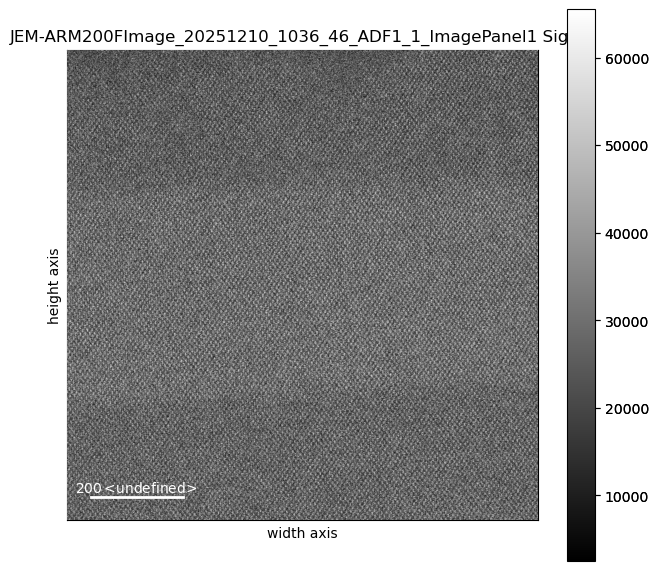

In [5]:
s[0].plot()

In [ ]:
s[1].plot()

In [6]:
s[0].axes_manager.gui()

In [ ]:
s[0].plot()

## Load an image stack (via HyperSpy's load() function)





In [7]:
tiffFilesWildcard = STACK_FOLDER_PATH + "/*.tif"
imgStack = hs.load(tiffFilesWildcard, stack=True)

#print(imgStack[0])
#imgStack[0]

print(type(imgStack))
print(len(imgStack))
#print(imgStack[0])
#print(imgStack[0].metadata)
#print("=================")
#print(imgStack[0].original_metadata)



  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

<class 'list'>
2


41712
28616


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:03<00:00,  2.98it/s]


  0%|          | 0/2 [00:00<?, ?it/s]

25215
25792


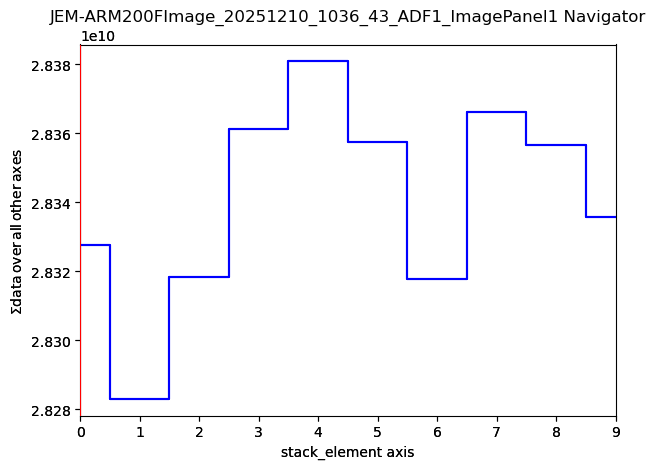

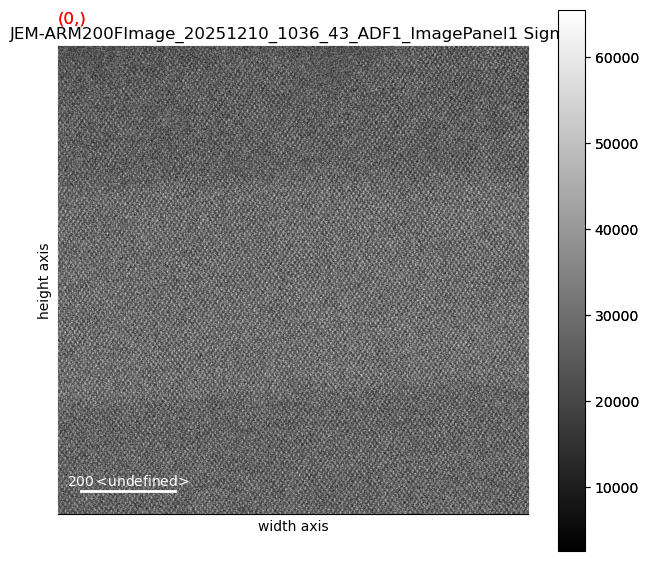

In [8]:
print(imgStack[0].data[0][0][30])
print(imgStack[0].data[1][0][30])

imgStack[0].align2D()
imgStack[0].plot()

print(imgStack[0].data[0][0][30])
print(imgStack[0].data[1][0][30])

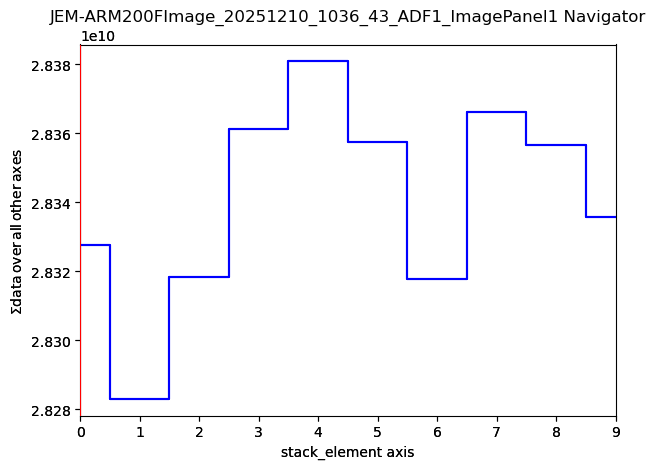

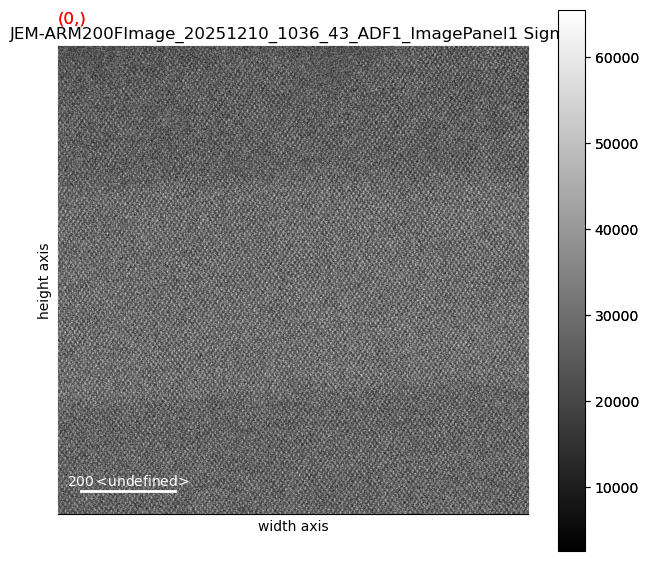

In [9]:
imgStack[0].axes_manager.gui()
imgStack[0].plot()

## Plot, Calibrate, and Remove Some Noise


Decomposition info:
  normalize_poissonian_noise=False
  algorithm=SVD
  output_dimension=None
  centre=None


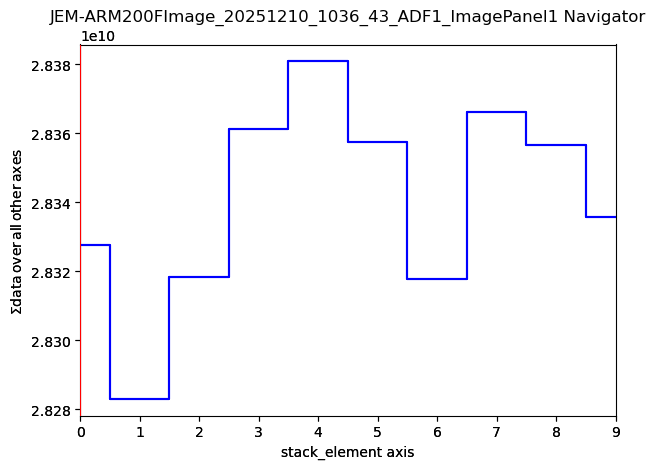

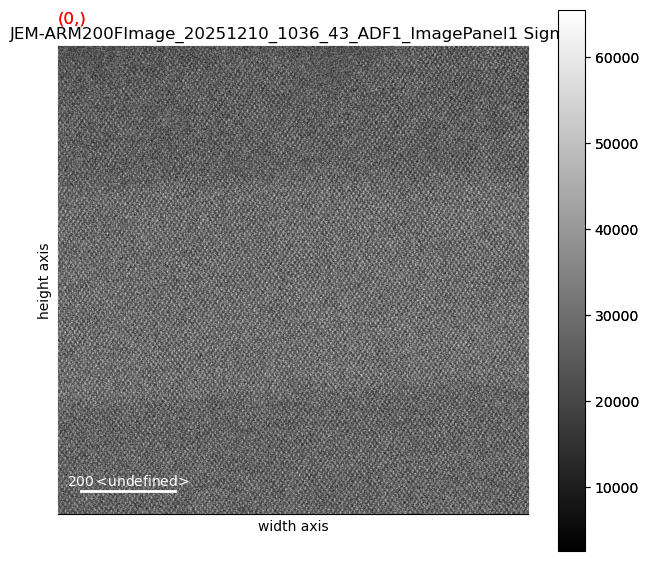

In [11]:
# it's currently full of 16 bit integers (0 to 65535). We need floating-point values for doing actual math. So we convert:
imgStack[0].change_dtype('float64')

imgStack[0].decomposition()    # taking ALL the defaults - a lot to understand here.

imgStack[0].plot()



In [ ]:
# save the filtered, shifted image to an HDF5 file

imgStack[0].save(OUTPUT_DIR + "/savedResult")

# calibrate
from ipywidgets import interact, widgets
%matplotlib widget 

imgStack[0].plot()
imgStack[0].calibrate(interactive=True)



In [ ]:
imgStack[0].axes_manager.gui()

In [ ]:
imgStack[0].plot()

## Directly Reading and Writing the Underlying Data

We can look directly into a Hyperspy signal object and access the exact data that respresents the image using any tools and techniques we want to.

In [ ]:
## Clipping and Gamma Correction


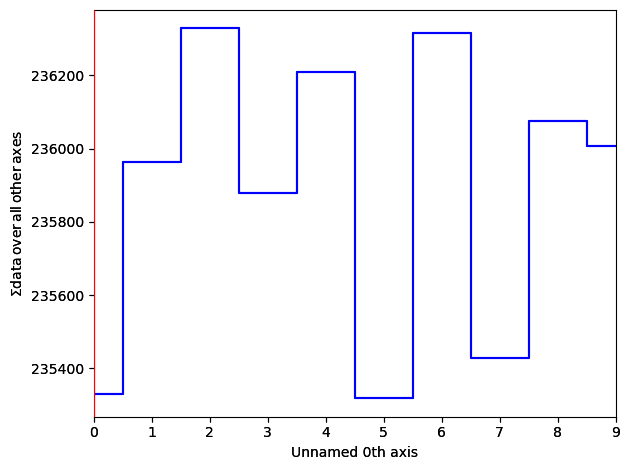

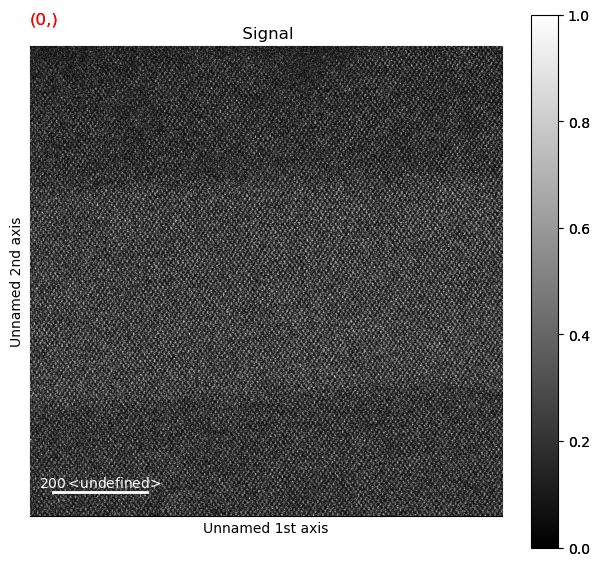

In [15]:

# Clipping

stack_n = np.empty_like(imgStack[0].data)
for i in range(imgStack[0].data.shape[0]):
    lo, hi = np.percentile(imgStack[0].data[i], [1, 99])
    stack_n[i] = np.clip((imgStack[0].data[i] - lo) / (hi - lo + 1e-12), 0, 1)

# Gamma correction
gamma = 1    # or 0.5, or 1.5, or whatever.  1 is identity, so don't expect much :-)
gamma_corrected = np.clip(stack_n ** gamma, 0 ,1)

    

freshNewHS = hs.signals.Signal2D(gamma_corrected)
freshNewHS.plot()


    

In [18]:
save_jpeg_thumbnail(gamma_corrected[0], "/tmp/gct.jpg")

# Extra Greebles:

In [ ]:
from PIL import Image
from PIL.TiffTags import TAGS

pimg = Image.open('/Users/escott/projects/CITEAM/notebooks/SiGe/JEM-ARM200FImage_20251210_1036_43_ADF1_ImagePanel1/JEM-ARM200FImage_20251210_1036_56_ADF1_4_ImagePanel1.tif')
blah = 2
for key, value in pimg.tag.items():
    print(f"{key}: {value}")
print("=========")
print(pimg.tag["Resolution"])
    
#with Image.open('/Users/escott/projects/CITEAM/notebooks/SiGe/JEM-ARM200FImage_20251210_1036_43_ADF1_ImagePanel1/JEM-ARM200FImage_20251210_1036_56_ADF1_4_ImagePanel1.tif') as pimg:
#    for key in pimg.tag_v2.tags:
#        print(key)
    
#    meta_dict = {TAGS[key] : pimg.tag[key] for key in pimg.tag.iterkeys()}






